<a href="https://colab.research.google.com/github/VictorHo1114/ERP_Kaggle_PricePredict/blob/master/ERP_PythonTeam_PricePrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ==========================================
# Cell 1: 匯入核心套件與環境設定
# ==========================================
!pip install catboost -q
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import time

# Scikit-learn
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, IterativeImputer
from sklearn.preprocessing import RobustScaler, OrdinalEncoder, TargetEncoder
from sklearn.linear_model import BayesianRidge, RidgeCV
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.feature_selection import mutual_info_regression
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.base import clone

# 三大 Boosting 模型
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

# 全域隨機種子
SEED = 42
np.random.seed(SEED)

# 圖表風格
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.1)
%matplotlib inline

# 只抑制特定警告
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

print("✅ 套件匯入成功！（XGBoost + LightGBM + CatBoost + Stacking）")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.2 MB/s eta 0:00:00
✅ 套件匯入成功！（XGBoost + LightGBM + CatBoost + Stacking）


In [2]:
# ==========================================
# Cell 2: 讀取資料與基本資訊
# ==========================================
train_path = './data/train.csv'

try:
    df_train = pd.read_csv(train_path)
    print(f"✅ 訓練集讀取成功！資料維度: {df_train.shape}")
except FileNotFoundError:
    print(f"❌ 找不到檔案，請確認路徑: {train_path}")
    # 這裡建立一個模擬資料集讓你測試 Notebook 能否順利跑動
    np.random.seed(42)
    n = 1000
    df_train = pd.DataFrame({
        'id': range(n),
        'Compartments': np.random.randint(1, 5, n),
        'Weight Capacity (kg)': np.random.uniform(5, 30, n),
        'Size': np.random.choice(['Small', 'Medium', 'Large'], n),
        'Laptop Compartment': np.random.choice(['Yes', 'No'], n),
        'Waterproof': np.random.choice(['Yes', 'No'], n),
        'Brand': np.random.choice(['BrandA', 'BrandB', 'BrandC'], n),
        'Material': np.random.choice(['Nylon', 'Leather', 'Canvas'], n),
        'Style': np.random.choice(['Casual', 'Business', 'Sport'], n),
        'Color': np.random.choice(['Black', 'Blue', 'Red'], n),
        'Price': np.random.normal(3000, 500, n)
    })
    # 製造缺失值
    df_train.loc[10:50, 'Weight Capacity (kg)'] = np.nan
    df_train.loc[100:150, 'Size'] = np.nan

display(df_train.head())

# 分離特徵與標籤
X = df_train.drop(columns=['id', 'Price'], errors='ignore')
y = df_train['Price'] if 'Price' in df_train.columns else None

✅ 訓練集讀取成功！資料維度: (300000, 11)


,id,Brand,Material,Size,Compartments,Laptop Compartment,Waterproof,Style,Color,Weight Capacity (kg),Price
0,0,Jansport,Leather,Medium,7.0,Yes,No,Tote,Black,11.611723,112.15875
1,1,Jansport,Canvas,Small,10.0,Yes,Yes,Messenger,Green,27.078537,68.88056
2,2,Under Armour,Leather,Small,2.0,Yes,No,Messenger,Red,16.643760,39.17320
3,3,Nike,Nylon,Small,8.0,Yes,No,Messenger,Green,12.937220,80.60793
4,4,Adidas,Canvas,Medium,1.0,Yes,Yes,Messenger,Green,17.749338,86.02312


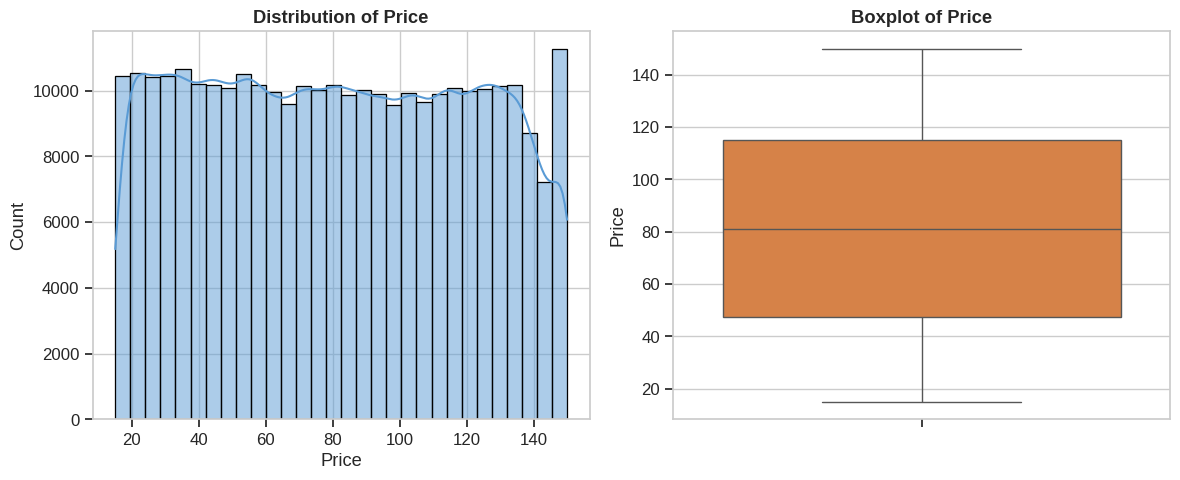

💡 Price 偏態係數 (Skewness): 0.04


In [3]:
# ==========================================
# Cell 3: Target (Price) 分佈分析
# ==========================================
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(y, kde=True, color='#5A9BD5', bins=30)
plt.title('Distribution of Price', fontweight='bold')
plt.xlabel('Price')

plt.subplot(1, 2, 2)
sns.boxplot(y=y, color='#ED7D31')
plt.title('Boxplot of Price', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"💡 Price 偏態係數 (Skewness): {y.skew():.2f}")

⚠️ 發現 8 個特徵包含缺失值。


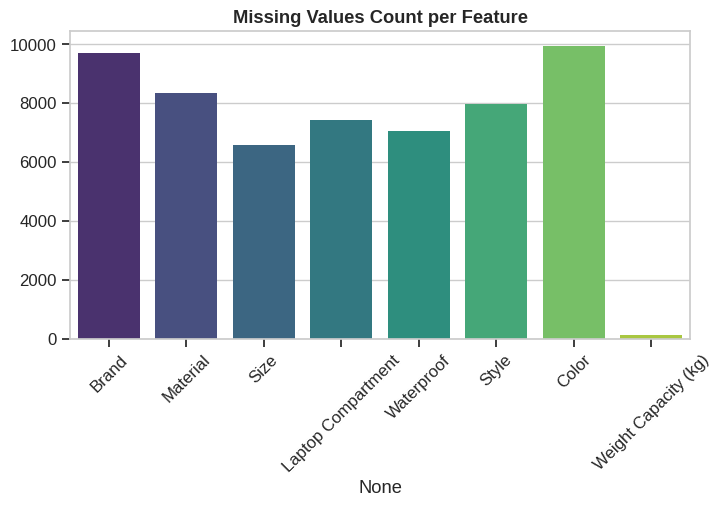


💡 觀察缺失值的共現矩陣 (Nullity Correlation)：


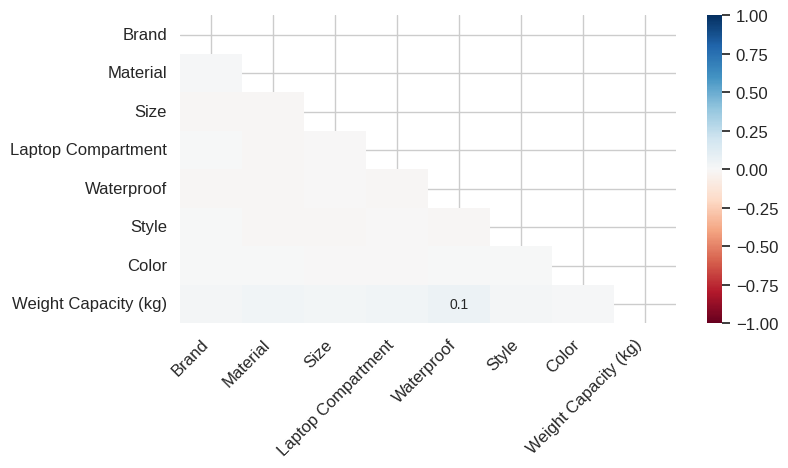

In [4]:
# ==========================================
# Cell 4: 缺失值結構視覺化 (Missing Data Patterns)
# ==========================================
missing_counts = X.isnull().sum()
missing_features = missing_counts[missing_counts > 0].index.tolist()

if len(missing_features) > 0:
    print(f"⚠️ 發現 {len(missing_features)} 個特徵包含缺失值。")

    plt.figure(figsize=(8, 4))
    sns.barplot(x=missing_counts[missing_features].index, y=missing_counts[missing_features].values, palette='viridis')
    plt.title('Missing Values Count per Feature', fontweight='bold')
    plt.xticks(rotation=45)
    plt.show()

    print("\n💡 觀察缺失值的共現矩陣 (Nullity Correlation)：")
    msno.heatmap(X[missing_features], figsize=(8, 4), fontsize=12)
    plt.show()
else:
    print("✅ 資料集中沒有缺失值！")

📊 1. 數值特徵分佈


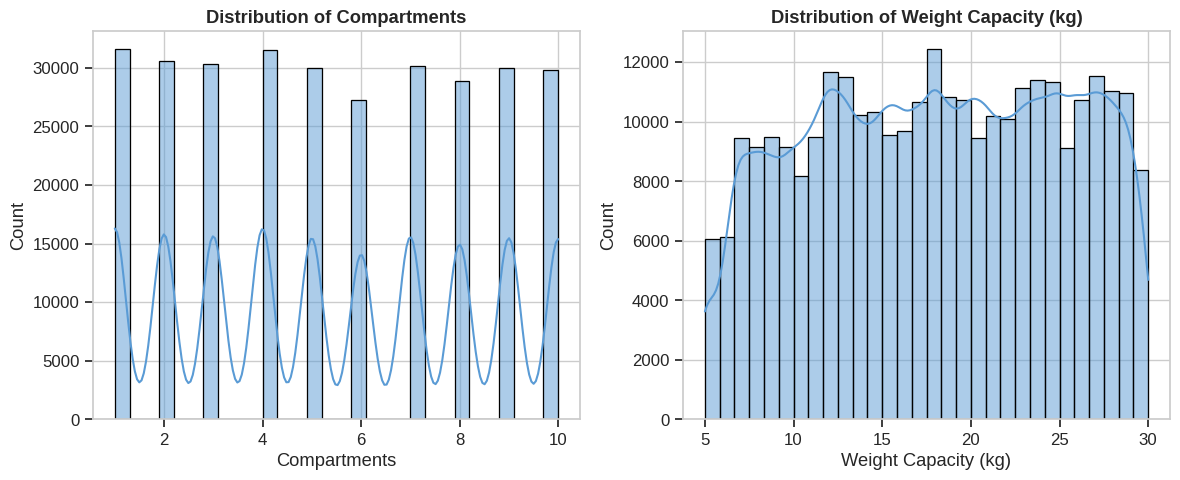


📊 2. 數值特徵 vs Price (Scatter)


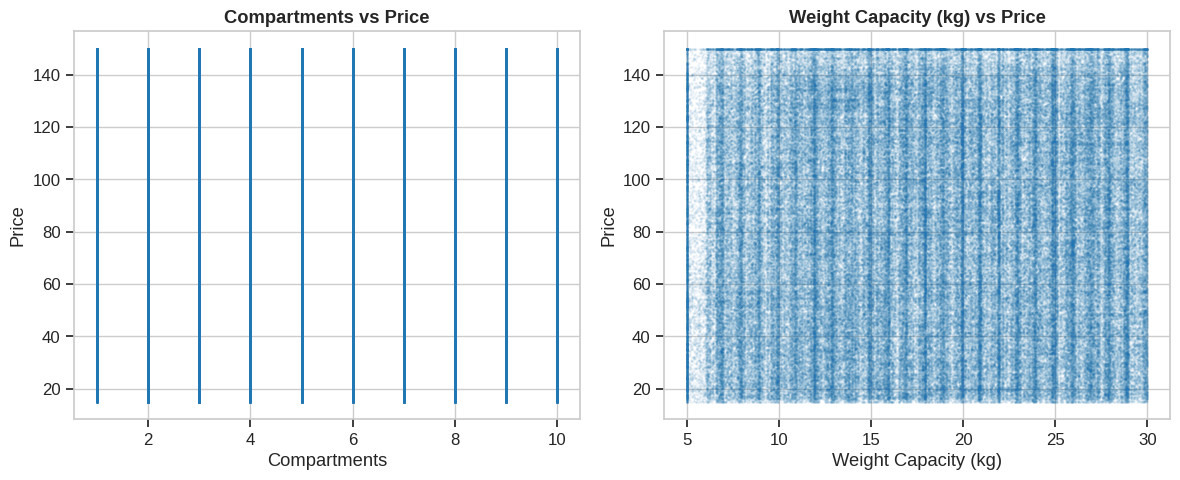


📊 3. 數值特徵 Correlation Heatmap


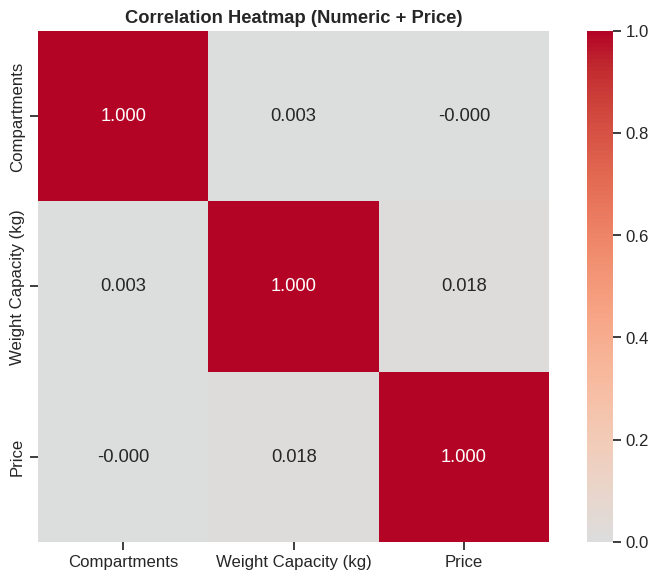


📊 4. 所有類別特徵 vs Price


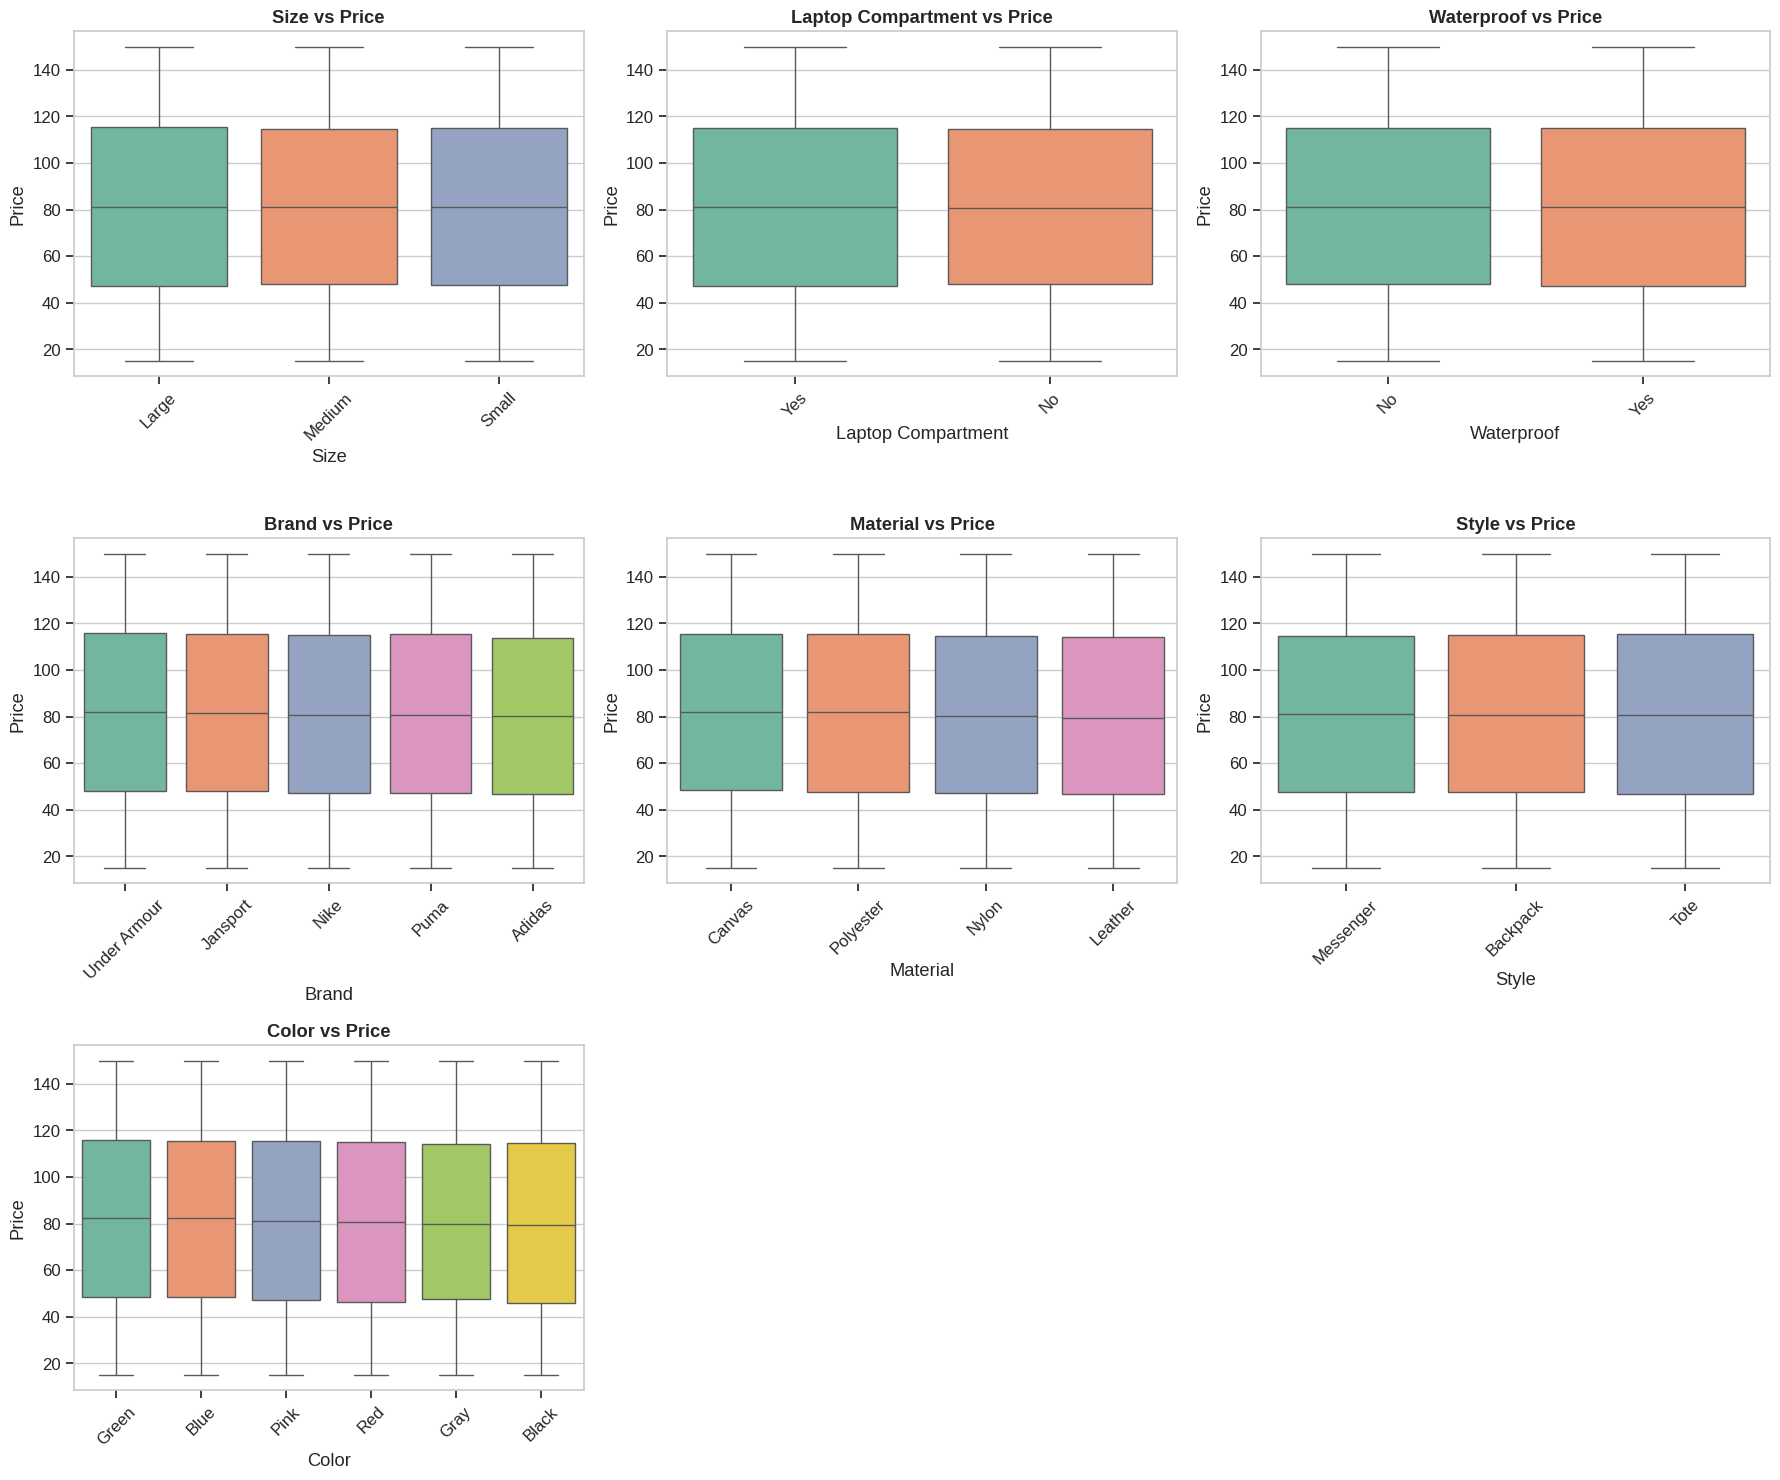


📊 5. 類別特徵 Value Counts (檢查類別不平衡)

  Size:
    Medium              : 101906 ( 34.0%)
    Large               :  98643 ( 32.9%)
    Small               :  92856 ( 31.0%)

  Laptop Compartment:
    Yes                 : 148342 ( 49.4%)
    No                  : 144214 ( 48.1%)

  Waterproof:
    Yes                 : 148077 ( 49.4%)
    No                  : 144873 ( 48.3%)

  Brand:
    Adidas              :  60077 ( 20.0%)
    Under Armour        :  59992 ( 20.0%)
    Nike                :  57336 ( 19.1%)
    Puma                :  56814 ( 18.9%)
    Jansport            :  56076 ( 18.7%)

  Material:
    Polyester           :  79630 ( 26.5%)
    Leather             :  73416 ( 24.5%)
    Nylon               :  70603 ( 23.5%)
    Canvas              :  68004 ( 22.7%)

  Style:
    Messenger           : 100031 ( 33.3%)
    Tote                :  97438 ( 32.5%)
    Backpack            :  94561 ( 31.5%)

  Color:
    Pink                :  51690 ( 17.2%)
    Gray                :  50280 ( 1

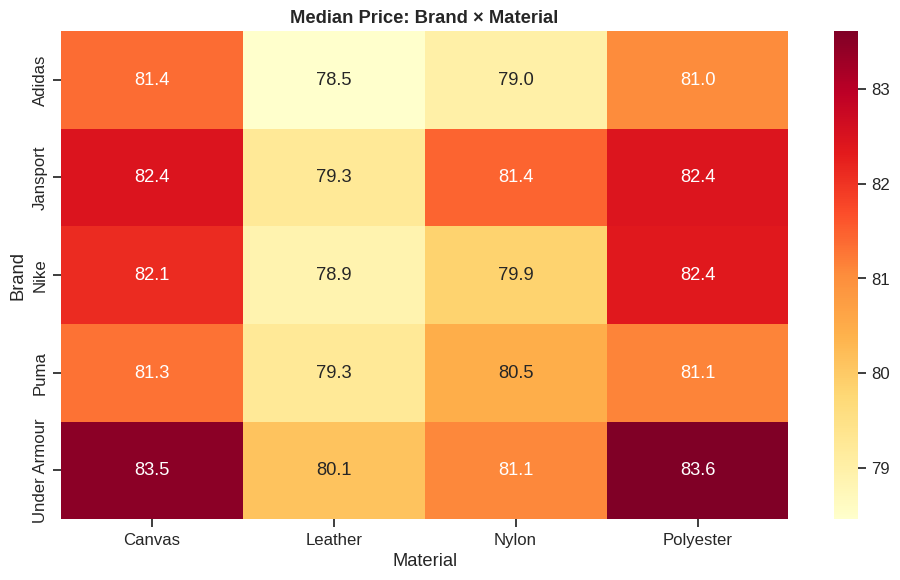

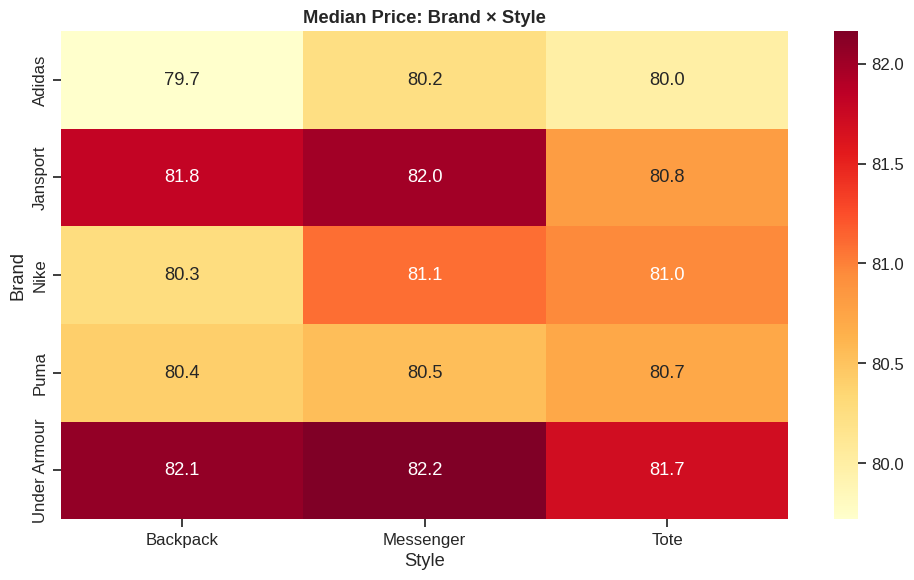

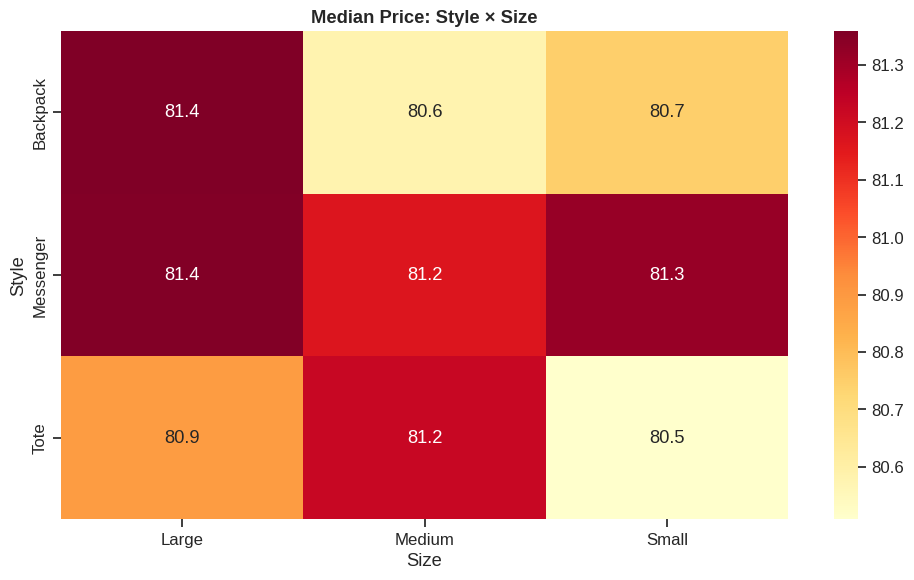


📊 7. Outlier 偵測 (IQR 法)
  Compartments                  :      0 outliers (0.00%)
  Weight Capacity (kg)          :      0 outliers (0.00%)
  Price                         :      0 outliers (0.00%)

🔍 Price 最高 5 筆:


,id,Brand,Material,Size,Compartments,Laptop Compartment,Waterproof,Style,Color,Weight Capacity (kg),Price
111,111,Adidas,Canvas,Large,8.0,No,No,Messenger,Gray,18.629323,150.0
263,263,Jansport,Canvas,Large,7.0,No,No,Tote,Green,8.412719,150.0
278,278,Jansport,Nylon,NaN,2.0,Yes,No,NaN,Gray,28.125328,150.0
318,318,Nike,NaN,Large,3.0,No,Yes,Tote,Red,11.994718,150.0
333,333,Jansport,Leather,Large,1.0,Yes,Yes,Messenger,NaN,15.274816,150.0



🔍 Price 最低 5 筆:


,id,Brand,Material,Size,Compartments,Laptop Compartment,Waterproof,Style,Color,Weight Capacity (kg),Price
345,345,Puma,Leather,Large,8.0,No,No,Messenger,Red,23.851121,15.0
363,363,Nike,Nylon,Small,2.0,Yes,Yes,Messenger,Green,14.587918,15.0
540,540,Jansport,NaN,Large,6.0,No,Yes,Backpack,Gray,16.959719,15.0
1115,1115,Puma,Polyester,Medium,1.0,No,Yes,Messenger,Green,23.857206,15.0
1189,1189,Jansport,Leather,Small,2.0,No,No,NaN,Gray,27.307780,15.0



📊 8. Pairplot (數值特徵 + Price)


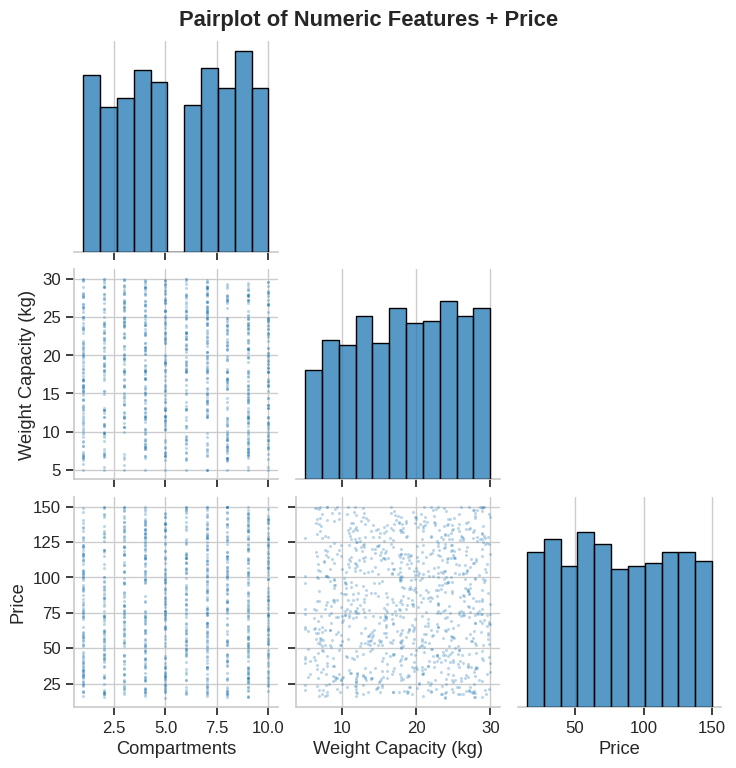


📊 9. 缺失值與 Price 的關係 (MCAR / MAR / MNAR 判斷)


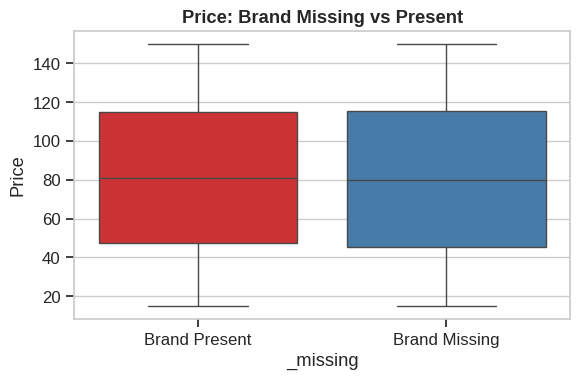

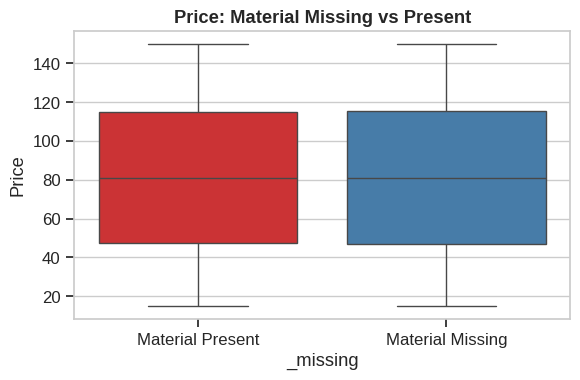

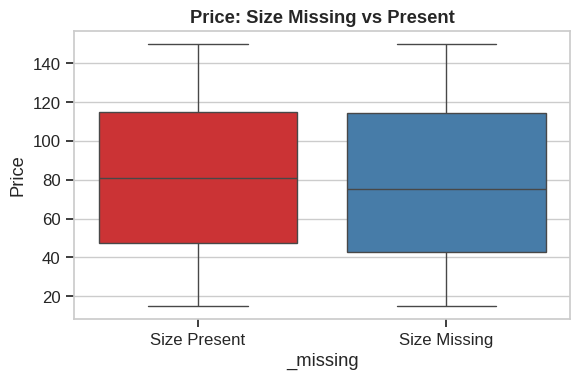

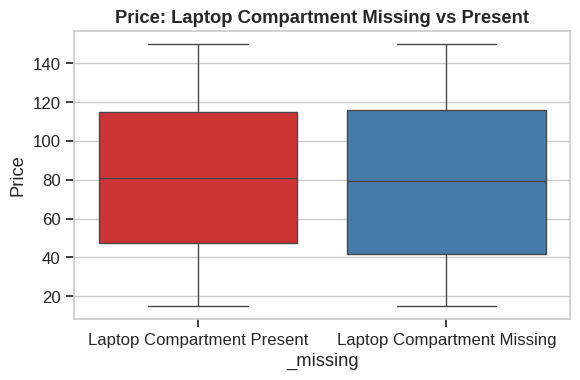

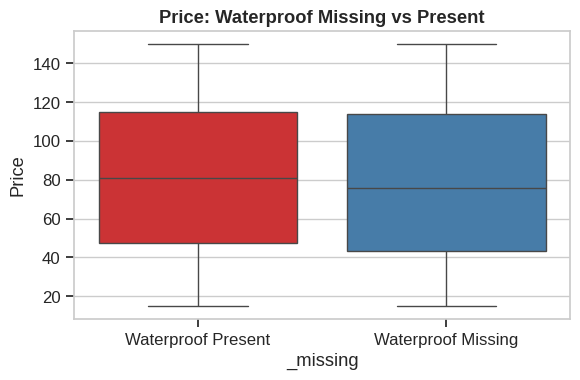

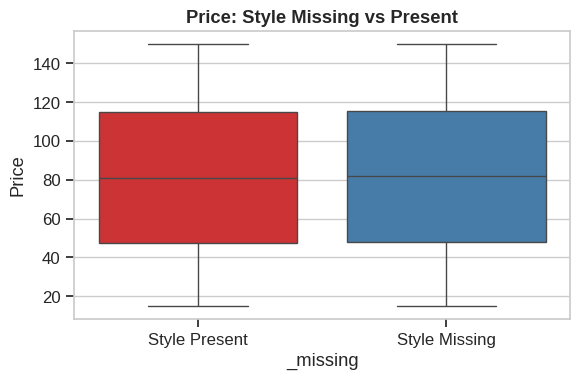

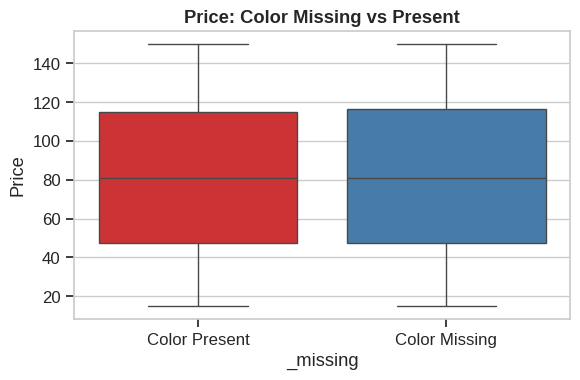

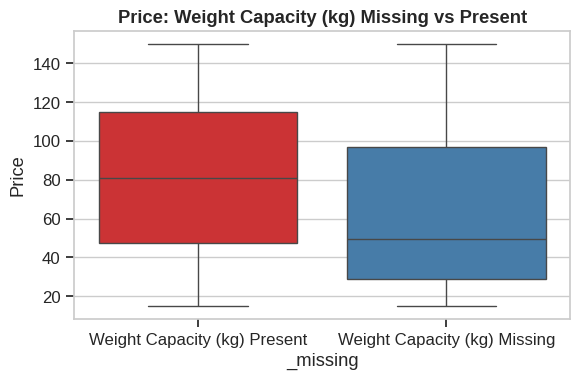


✅ EDA 完成！以上觀察可用於指導 Feature Engineering 與 Preprocessing 決策。


In [6]:
# ==========================================
# Cell 4.5: 完整 EDA（數值分佈、交互作用、Outlier、多變量、缺失值進階）
# ==========================================

# 先定義特徵分類（跟 Cell 6 一致）
numeric_features = ['Compartments', 'Weight Capacity (kg)']
ordinal_features = ['Size', 'Laptop Compartment', 'Waterproof']
nominal_features = ['Brand', 'Material', 'Style', 'Color']
# ---- 1. 數值特徵分佈 ----

print("=" * 60)
print("📊 1. 數值特徵分佈")
print("=" * 60)

fig, axes = plt.subplots(1, len(numeric_features), figsize=(6 * len(numeric_features), 5))
if len(numeric_features) == 1:
    axes = [axes]
for ax, col in zip(axes, numeric_features):
    sns.histplot(df_train[col].dropna(), kde=True, ax=ax, color='#5A9BD5', bins=30)
    ax.set_title(f'Distribution of {col}', fontweight='bold')
plt.tight_layout()
plt.show()

# ---- 2. 數值特徵 vs Price scatter ----
print("\n" + "=" * 60)
print("📊 2. 數值特徵 vs Price (Scatter)")
print("=" * 60)

fig, axes = plt.subplots(1, len(numeric_features), figsize=(6 * len(numeric_features), 5))
if len(numeric_features) == 1:
    axes = [axes]
for ax, col in zip(axes, numeric_features):
    ax.scatter(df_train[col], df_train['Price'], alpha=0.05, s=1)
    ax.set_xlabel(col)
    ax.set_ylabel('Price')
    ax.set_title(f'{col} vs Price', fontweight='bold')
plt.tight_layout()
plt.show()

# ---- 3. Correlation Heatmap ----
print("\n" + "=" * 60)
print("📊 3. 數值特徵 Correlation Heatmap")
print("=" * 60)

corr_cols = numeric_features + ['Price']
corr_matrix = df_train[corr_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Heatmap (Numeric + Price)', fontweight='bold')
plt.tight_layout()
plt.show()

# ---- 4. 所有類別特徵 vs Price boxplot ----
print("\n" + "=" * 60)
print("📊 4. 所有類別特徵 vs Price")
print("=" * 60)

cat_features = ordinal_features + nominal_features
n_cols = 3
n_rows = (len(cat_features) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    if col in df_train.columns:
        order = df_train.groupby(col)['Price'].median().sort_values(ascending=False).index
        sns.boxplot(x=col, y='Price', data=df_train, ax=axes[i], order=order, palette='Set2')
        axes[i].set_title(f'{col} vs Price', fontweight='bold')
        axes[i].tick_params(axis='x', rotation=45)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

# ---- 5. 類別特徵 Value Counts ----
print("\n" + "=" * 60)
print("📊 5. 類別特徵 Value Counts (檢查類別不平衡)")
print("=" * 60)

for col in cat_features:
    if col in df_train.columns:
        vc = df_train[col].value_counts()
        print(f"\n  {col}:")
        for val, cnt in vc.items():
            pct = cnt / len(df_train) * 100
            print(f"    {val:20s}: {cnt:>6} ({pct:>5.1f}%)")

# ---- 6. 交互作用 Heatmap ----
print("\n" + "=" * 60)
print("📊 6. 類別特徵交互作用 (Median Price Heatmap)")
print("=" * 60)

interaction_pairs = [('Brand', 'Material'), ('Brand', 'Style'), ('Style', 'Size')]
for f1, f2 in interaction_pairs:
    if f1 in df_train.columns and f2 in df_train.columns:
        pivot = df_train.pivot_table(values='Price', index=f1, columns=f2, aggfunc='median')
        plt.figure(figsize=(10, 6))
        sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd')
        plt.title(f'Median Price: {f1} × {f2}', fontweight='bold')
        plt.tight_layout()
        plt.show()

# ---- 7. Outlier 偵測 ----
print("\n" + "=" * 60)
print("📊 7. Outlier 偵測 (IQR 法)")
print("=" * 60)

for col in numeric_features + ['Price']:
    Q1 = df_train[col].quantile(0.25)
    Q3 = df_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df_train[col] < lower) | (df_train[col] > upper)).sum()
    pct = n_outliers / len(df_train) * 100
    print(f"  {col:30s}: {n_outliers:>6} outliers ({pct:.2f}%)")

print("\n🔍 Price 最高 5 筆:")
display(df_train.nlargest(5, 'Price'))
print("\n🔍 Price 最低 5 筆:")
display(df_train.nsmallest(5, 'Price'))

# ---- 8. Pairplot (取樣) ----
print("\n" + "=" * 60)
print("📊 8. Pairplot (數值特徵 + Price)")
print("=" * 60)

sample = df_train.sample(min(1000, len(df_train)), random_state=SEED)
sns.pairplot(sample[numeric_features + ['Price']], corner=True, plot_kws={'alpha': 0.3, 's': 5})
plt.suptitle('Pairplot of Numeric Features + Price', y=1.02, fontweight='bold')
plt.show()

# ---- 9. 缺失值 vs Price 的關係 ----
print("\n" + "=" * 60)
print("📊 9. 缺失值與 Price 的關係 (MCAR / MAR / MNAR 判斷)")
print("=" * 60)

if len(missing_features) > 0:
    for col in missing_features:
        df_train['_missing'] = df_train[col].isna().map({True: f'{col} Missing', False: f'{col} Present'})
        fig, ax = plt.subplots(figsize=(6, 4))
        sns.boxplot(x='_missing', y='Price', data=df_train, ax=ax, palette='Set1')
        ax.set_title(f'Price: {col} Missing vs Present', fontweight='bold')
        plt.tight_layout()
        plt.show()
    df_train.drop(columns=['_missing'], inplace=True, errors='ignore')
else:
    print("  ✅ 無缺失值，跳過此分析。")

print("\n✅ EDA 完成！以上觀察可用於指導 Feature Engineering 與 Preprocessing 決策。")

In [ ]:
# ==========================================
# Cell 5: 類別特徵對價格的影響 (Categorical vs Target)
# ==========================================
features_to_plot = ['Brand', 'Material', 'Style']

fig, axes = plt.subplots(1, len(features_to_plot), figsize=(18, 5))

for i, col in enumerate(features_to_plot):
    if col in df_train.columns:
        order = df_train.groupby(col)['Price'].median().sort_values(ascending=False).index
        sns.boxplot(x=col, y='Price', data=df_train, ax=axes[i], order=order, palette='Set2')
        axes[i].set_title(f'{col} vs Price', fontweight='bold')
        axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# Cell 6: 建構黃金前處理管線 (IterativeImputer + TargetEncoder)
# ==========================================
print("⏳ 正在建立前處理管線...")

# 定義特徵分類
numeric_features = ['Compartments', 'Weight Capacity (kg)']
ordinal_features = ['Size', 'Laptop Compartment', 'Waterproof']
nominal_features = ['Brand', 'Material', 'Style', 'Color']

size_cats = ['Small', 'Medium', 'Large']
yes_no_cats = ['No', 'Yes']

# 1. 數值：IterativeImputer (MICE) + RobustScaler
num_pipeline = Pipeline([
    ('imputer', IterativeImputer(estimator=BayesianRidge(), random_state=42, max_iter=10)),
    ('scaler', RobustScaler())
])

# 2. 序數：眾數補值 + 順序編碼
ord_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=[size_cats, yes_no_cats, yes_no_cats],
                               handle_unknown='use_encoded_value', unknown_value=-1))
])

# 3. 名目：缺失值獨立為 Unknown + Target Encoding
nom_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('encoder', TargetEncoder(target_type='continuous', random_state=42))
])

# 組合為 ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, numeric_features),
        ('ord', ord_pipeline, ordinal_features),
        ('nom', nom_pipeline, nominal_features)
    ], remainder='drop'
)

# 儲存轉換後的欄位順序，供 MI 分析使用
feature_names_ordered = numeric_features + ordinal_features + nominal_features

print("✅ 前處理管線建立完成！")

In [ ]:
# ==========================================
# Cell 7: 純淨版 Mutual Information 分析 (排除補值干擾)
# ==========================================
from sklearn.preprocessing import OrdinalEncoder as _OrdEnc

print("🔍 正在計算各特徵最純粹的 MI 分數 (排除 NaN 干擾)...")

mi_results = {}
all_features = numeric_features + ordinal_features + nominal_features

for col in all_features:
    valid_idx = df_train[col].notna()
    if valid_idx.sum() == 0:
        continue

    X_valid = df_train.loc[valid_idx, [col]].copy()
    y_valid = df_train.loc[valid_idx, 'Price'].copy()

    is_discrete = X_valid[col].dtype == 'object' or col in ordinal_features

    if X_valid[col].dtype == 'object':
        temp_encoder = _OrdEnc(handle_unknown='use_encoded_value', unknown_value=-1)
        X_valid[col] = temp_encoder.fit_transform(X_valid[[col]])

    score = mutual_info_regression(
        X_valid, y_valid,
        discrete_features=[is_discrete],
        random_state=SEED
    )[0]
    mi_results[col] = score

mi_scores_df = (
    pd.DataFrame(list(mi_results.items()), columns=['Feature', 'MI_Score'])
    .sort_values(by='MI_Score', ascending=False)
)

plt.figure(figsize=(10, 6))
sns.barplot(x='MI_Score', y='Feature', data=mi_scores_df, palette='magma')
plt.title('True Mutual Information Scores (排除補值干擾版)', fontsize=15, fontweight='bold')
plt.xlabel('MI Score (越高關聯越強)')
plt.ylabel('Features')
plt.axvline(x=0.01, color='red', linestyle='--', label='Drop Threshold')
plt.legend()
plt.tight_layout()
plt.show()

display(mi_scores_df)

MI_THRESHOLD = 0.01
low_mi_features = mi_scores_df.loc[mi_scores_df['MI_Score'] < MI_THRESHOLD, 'Feature'].tolist()
print(f"\n💡 MI < {MI_THRESHOLD} 的特徵: {low_mi_features if low_mi_features else '無 (全部保留)'}")

In [ ]:
# ==========================================
# Cell 8: Imputer Ablation + 三模型 Early Stopping CV + Stacking
# ==========================================
print("🚀 啟動完整評估：Imputer Ablation → XGB / LGB / CatBoost → Stacking\n")

# ---- 1. 根據 MI 篩選特徵 ----
final_numeric = [f for f in numeric_features if f not in low_mi_features]
final_ordinal = [f for f in ordinal_features if f not in low_mi_features]
final_nominal = [f for f in nominal_features if f not in low_mi_features]

print(f"  數值特徵: {final_numeric}")
print(f"  序數特徵: {final_ordinal}")
print(f"  名目特徵: {final_nominal}")

# ---- 2. 動態建立 ordinal categories ----
ordinal_cat_map = {
    'Size': ['Small', 'Medium', 'Large'],
    'Laptop Compartment': ['No', 'Yes'],
    'Waterproof': ['No', 'Yes']
}
final_ord_categories = [ordinal_cat_map[col] for col in final_ordinal]

# ---- 3. Imputer Ablation：三種策略 ----
imputer_configs = {
    'median': SimpleImputer(strategy='median'),
    'MICE_linear': IterativeImputer(estimator=BayesianRidge(), random_state=SEED, max_iter=10),
    'MICE_tree': IterativeImputer(
        estimator=ExtraTreesRegressor(n_estimators=50, max_depth=5, random_state=SEED),
        random_state=SEED, max_iter=10
    ),
}

def build_preprocessor(num_imputer):
    """根據給定的 imputer 建立完整 preprocessor"""
    _num_pipe = Pipeline([
        ('imputer', num_imputer),
        ('scaler', RobustScaler())
    ])
    _ord_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OrdinalEncoder(
            categories=final_ord_categories,
            handle_unknown='use_encoded_value', unknown_value=-1
        ))
    ])
    _nom_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
        ('encoder', TargetEncoder(target_type='continuous', random_state=SEED))
    ])
    return ColumnTransformer(
        transformers=[
            ('num', _num_pipe, final_numeric),
            ('ord', _ord_pipe, final_ordinal),
            ('nom', _nom_pipe, final_nominal)
        ], remainder='drop'
    )

# 快速 ablation：用 XGBoost 作為固定模型，只換 imputer
print("\n📊 Imputer Ablation (3-Fold 快速評估):")
ablation_kf = KFold(n_splits=3, shuffle=True, random_state=SEED)
ablation_results = {}

for imp_name, imp in imputer_configs.items():
    fold_rmses = []
    for train_idx, val_idx in ablation_kf.split(X):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        prep = build_preprocessor(clone(imp))
        X_tr_t = prep.fit_transform(X_tr, y_tr)
        X_val_t = prep.transform(X_val)

        m = xgb.XGBRegressor(
            n_estimators=500, max_depth=6, learning_rate=0.05,
            tree_method='hist', early_stopping_rounds=30,
            random_state=SEED, n_jobs=-1, verbosity=0
        )
        m.fit(X_tr_t, y_tr, eval_set=[(X_val_t, y_val)], verbose=False)
        pred = m.predict(X_val_t)
        fold_rmses.append(np.sqrt(mean_squared_error(y_val, pred)))

    avg_rmse = np.mean(fold_rmses)
    ablation_results[imp_name] = avg_rmse
    print(f"  {imp_name:15s} → RMSE = {avg_rmse:.4f}")

best_imputer_name = min(ablation_results, key=ablation_results.get)
best_imputer = imputer_configs[best_imputer_name]
print(f"\n✅ 最佳 Imputer: {best_imputer_name} (RMSE = {ablation_results[best_imputer_name]:.4f})")

# ---- 4. 用最佳 imputer 建立最終 preprocessor ----
final_preprocessor = build_preprocessor(clone(best_imputer))

# ---- 5. StratifiedKFold (對 Price 做 binning) ----
y_binned = pd.qcut(y, q=10, labels=False, duplicates='drop')
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# ---- 6. 三模型 CV + 收集 OOF predictions 用於 Stacking ----
n_samples = len(X)
oof_preds = {
    'xgb': np.zeros(n_samples),
    'lgb': np.zeros(n_samples),
    'cat': np.zeros(n_samples),
}
model_cv_scores = {'xgb': [], 'lgb': [], 'cat': []}
best_iters = {'xgb': [], 'lgb': [], 'cat': []}

feature_names_final = final_numeric + final_ordinal + final_nominal
start_time = time.time()

print("\n🏋️ 開始 5-Fold Stratified CV（三模型同步訓練）...\n")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y_binned), 1):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # Preprocessor: fit on train, transform both
    prep = build_preprocessor(clone(best_imputer))
    X_tr_t = prep.fit_transform(X_tr, y_tr)
    X_val_t = prep.transform(X_val)

    # --- XGBoost ---
    xgb_m = xgb.XGBRegressor(
        n_estimators=1000, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0,
        tree_method='hist', early_stopping_rounds=50,
        random_state=SEED, n_jobs=-1, verbosity=0
    )
    xgb_m.fit(X_tr_t, y_tr, eval_set=[(X_val_t, y_val)], verbose=False)
    xgb_pred = xgb_m.predict(X_val_t)
    oof_preds['xgb'][val_idx] = xgb_pred
    best_iters['xgb'].append(xgb_m.best_iteration)

    # --- LightGBM ---
    lgb_m = lgb.LGBMRegressor(
        n_estimators=1000, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0,
        random_state=SEED, n_jobs=-1, verbose=-1
    )
    lgb_m.fit(
        X_tr_t, y_tr,
        eval_set=[(X_val_t, y_val)],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(period=0)]
    )
    lgb_pred = lgb_m.predict(X_val_t)
    oof_preds['lgb'][val_idx] = lgb_pred
    best_iters['lgb'].append(lgb_m.best_iteration_)

    # --- CatBoost ---
    cat_m = CatBoostRegressor(
        iterations=1000, depth=6, learning_rate=0.05,
        subsample=0.8, rsm=0.8,  # rsm = colsample_bytree equivalent
        l2_leaf_reg=3.0,
        random_seed=SEED, verbose=0
    )
    cat_m.fit(X_tr_t, y_tr, eval_set=(X_val_t, y_val), early_stopping_rounds=50)
    cat_pred = cat_m.predict(X_val_t)
    oof_preds['cat'][val_idx] = cat_pred
    best_iters['cat'].append(cat_m.best_iteration_)

    # 計算各模型在此 fold 的 metrics
    for name, pred in [('xgb', xgb_pred), ('lgb', lgb_pred), ('cat', cat_pred)]:
        rmse = np.sqrt(mean_squared_error(y_val, pred))
        model_cv_scores[name].append(rmse)

    print(f"  Fold {fold}: XGB={model_cv_scores['xgb'][-1]:.4f}  "
          f"LGB={model_cv_scores['lgb'][-1]:.4f}  "
          f"CAT={model_cv_scores['cat'][-1]:.4f}")

# ---- 7. CV 結果總覽 (多 metric) ----
elapsed = time.time() - start_time
print(f"\n✅ 完成！耗時: {elapsed:.1f} 秒\n")
print("=" * 65)
print(f"{'Model':<8} {'RMSE (CV)':>14} {'MAE (OOF)':>14} {'R² (OOF)':>12} {'Avg Iter':>10}")
print("=" * 65)

for name in ['xgb', 'lgb', 'cat']:
    rmse_mean = np.mean(model_cv_scores[name])
    rmse_std = np.std(model_cv_scores[name])
    mae = mean_absolute_error(y, oof_preds[name])
    r2 = r2_score(y, oof_preds[name])
    avg_iter = int(np.mean(best_iters[name]))
    print(f"{name.upper():<8} {rmse_mean:>7.4f}±{rmse_std:.4f} {mae:>14.4f} {r2:>12.4f} {avg_iter:>10}")

# ---- 8. Stacking：用 Ridge 做 meta-learner ----
print("\n🔗 Stacking: Ridge meta-learner on OOF predictions...")
meta_X = np.column_stack([oof_preds['xgb'], oof_preds['lgb'], oof_preds['cat']])
meta_model = RidgeCV(alphas=[0.001, 0.01, 0.1, 1.0, 10.0])
meta_model.fit(meta_X, y)

stacking_pred = meta_model.predict(meta_X)
stacking_rmse = np.sqrt(mean_squared_error(y, stacking_pred))
stacking_mae = mean_absolute_error(y, stacking_pred)
stacking_r2 = r2_score(y, stacking_pred)

print(f"\n{'STACK':<8} {'':>14} {stacking_mae:>14.4f} {stacking_r2:>12.4f}")
print(f"  Ridge alpha = {meta_model.alpha_}")
print(f"  Ridge weights = {np.round(meta_model.coef_, 4)}")
print(f"\n💡 注意：Stacking RMSE ({stacking_rmse:.4f}) 是 in-sample，僅供參考方向。")
print(f"   真正的泛化能力以各模型的 CV RMSE 為準。")

In [ ]:
# ==========================================
# Cell 9: 終極訓練、Feature Importance 與 Kaggle 提交
# ==========================================
import os

print("🏆 準備產出 Kaggle 提交檔案...\n")

# 1. 讀取測試集
test_path = './data/test.csv'
try:
    df_test = pd.read_csv(test_path)
    print(f"✅ 測試集讀取成功！資料維度: {df_test.shape}")
except FileNotFoundError:
    print(f"❌ 找不到測試集檔案，請確認路徑: {test_path}")
    df_test = pd.DataFrame({
        'id': range(1000, 1500),
        'Compartments': np.random.randint(1, 5, 500),
        'Weight Capacity (kg)': np.random.uniform(5, 30, 500),
        'Size': np.random.choice(['Small', 'Medium', 'Large'], 500),
        'Laptop Compartment': np.random.choice(['Yes', 'No'], 500),
        'Waterproof': np.random.choice(['Yes', 'No'], 500),
        'Brand': np.random.choice(['BrandA', 'BrandB', 'BrandC', 'NewBrand'], 500),
        'Material': np.random.choice(['Nylon', 'Leather', 'Canvas'], 500),
        'Style': np.random.choice(['Casual', 'Business', 'Sport'], 500),
        'Color': np.random.choice(['Black', 'Blue', 'Red'], 500)
    })

test_ids = df_test['id']
X_test = df_test.drop(columns=['id'])

# 2. 用全量資料 fit preprocessor
final_prep = build_preprocessor(clone(best_imputer))
X_all_t = final_prep.fit_transform(X, y)
X_test_t = final_prep.transform(X_test)

# 3. 訓練三個 base model（使用 CV 平均最佳迭代次數）
print(f"\n⏳ 全量訓練三模型...")

final_xgb = xgb.XGBRegressor(
    n_estimators=int(np.mean(best_iters['xgb'])),
    max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    tree_method='hist', random_state=SEED, n_jobs=-1, verbosity=0
)
final_xgb.fit(X_all_t, y)
print(f"  XGBoost done (n_estimators={final_xgb.n_estimators})")

final_lgb = lgb.LGBMRegressor(
    n_estimators=int(np.mean(best_iters['lgb'])),
    max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    random_state=SEED, n_jobs=-1, verbose=-1
)
final_lgb.fit(X_all_t, y)
print(f"  LightGBM done (n_estimators={final_lgb.n_estimators})")

final_cat = CatBoostRegressor(
    iterations=int(np.mean(best_iters['cat'])),
    depth=6, learning_rate=0.05,
    subsample=0.8, rsm=0.8,
    l2_leaf_reg=3.0,
    random_seed=SEED, verbose=0
)
final_cat.fit(X_all_t, y)
print(f"  CatBoost done (iterations={final_cat.tree_count_})")

# 4. Feature Importance 比較（三模型）
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, (name, model) in zip(axes, [('XGBoost', final_xgb), ('LightGBM', final_lgb), ('CatBoost', final_cat)]):
    if hasattr(model, 'feature_importances_'):
        imp = model.feature_importances_
    else:
        imp = model.get_feature_importance()

    imp_df = pd.DataFrame({
        'Feature': feature_names_final,
        'Importance': imp
    }).sort_values('Importance', ascending=False)

    sns.barplot(x='Importance', y='Feature', data=imp_df, palette='viridis', ax=ax)
    ax.set_title(f'{name} Feature Importance', fontweight='bold')

plt.tight_layout()
plt.show()

# 5. Stacking 預測
test_pred_xgb = final_xgb.predict(X_test_t)
test_pred_lgb = final_lgb.predict(X_test_t)
test_pred_cat = final_cat.predict(X_test_t)

meta_test_X = np.column_stack([test_pred_xgb, test_pred_lgb, test_pred_cat])
test_predictions = meta_model.predict(meta_test_X)

# 6. 產出提交檔
submission_df = pd.DataFrame({
    'id': test_ids,
    'Price': test_predictions
})

submission_filename = 'submission_stacking.csv'
submission_df.to_csv(submission_filename, index=False)

print(f"\n🎉 大功告成！提交檔案: {submission_filename}")
print(f"   Stacking weights: XGB={meta_model.coef_[0]:.3f}, LGB={meta_model.coef_[1]:.3f}, CAT={meta_model.coef_[2]:.3f}")
display(submission_df.head())

# 也產出各單模型的提交檔，方便你比較
for name, pred in [('xgb', test_pred_xgb), ('lgb', test_pred_lgb), ('cat', test_pred_cat)]:
    pd.DataFrame({'id': test_ids, 'Price': pred}).to_csv(f'submission_{name}.csv', index=False)
    print(f"  📄 submission_{name}.csv 已儲存")